## Chapter 10 Logistic Regression

**Original Code Credit:**: Shmueli, Galit; Bruce, Peter C.; Gedeck, Peter; Patel, Nitin R.. Machine Learning for Business Analytics Wiley.

*Modifications* have been made from the original textbook examples due to version changes in library dependencies and/or for clarity.

### Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from mord import LogisticIT
import matplotlib.pyplot as plt
import seaborn as sns
from dmba import classificationSummary, gainsChart, liftChart
from dmba.metric import AIC_score

import matplotlib

%matplotlib inline

SEED = 1

### 10.3 Example: Acceptance of Personal Loan

**Logistic regression model for loan acceptance (training data)**

In [2]:
bank_df = pd.read_csv(os.path.join('data', 'UniversalBank.csv'))
bank_df.drop(columns=['ID', 'ZIP Code'], inplace=True)
bank_df.columns = [c.replace(' ', '_') for c in bank_df.columns]

# Treat education as categorical, convert to dummy variables
bank_df['Education'] = bank_df['Education'].astype('category')
new_categories = {1: 'Undergrad', 2: 'Graduate', 3: 'Advanced/Professional'}
bank_df['Education'] = bank_df['Education'].cat.rename_categories(new_categories)
bank_df2 = pd.get_dummies(bank_df, prefix_sep='_', drop_first=True, dtype=int)

y = bank_df2['Personal_Loan']
X = bank_df2.drop(columns=['Personal_Loan'])

# partition data
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=SEED)

# fit a logistic regression (set penalty=l2 and C=1e42 to avoid regularization)
logit_reg = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg.fit(train_X, train_y)

print('intercept ', logit_reg.intercept_[0])
pd.DataFrame({'coeff': logit_reg.coef_[0]}, index=X.columns).transpose()

intercept  -12.560703103343736


,Age,Experience,Income,Family,CCAvg,Mortgage,Securities_Account,CD_Account,Online,CreditCard,Education_Graduate,Education_Advanced/Professional
coeff,-0.035686,0.037234,0.058921,0.61268,0.240926,0.001015,-1.029088,3.662056,-0.679537,-0.960725,4.21121,4.36177


In [3]:
print('AIC', AIC_score(valid_y, logit_reg.predict(valid_X), df = len(train_X.columns) + 1))

AIC -733.9975169177105


### 10.4 Evaluating Classification Performance

**Propensities for four customers in validation data**

In [4]:
logit_reg_pred = logit_reg.predict(valid_X)
logit_reg_proba = logit_reg.predict_proba(valid_X)
logit_result = pd.DataFrame({'actual': valid_y, 
                             'p(0)': [p[0] for p in logit_reg_proba],
                             'p(1)': [p[1] for p in logit_reg_proba],
                             'predicted': logit_reg_pred })
              
# display four different cases
interestingCases = [2764, 932, 2721, 702]
print(logit_result.loc[interestingCases])

      actual      p(0)      p(1)  predicted
2764       0  0.976165  0.023835          0
932        0  0.331940  0.668060          1
2721       1  0.031254  0.968746          1
702        1  0.985943  0.014057          0


**Training and Validation Confusion Matrices**

In [5]:
# training confusion matrix
classificationSummary(train_y, logit_reg.predict(train_X))

# validation confusion matrix
classificationSummary(valid_y, logit_reg.predict(valid_X))

Confusion Matrix (Accuracy 0.9600)

       Prediction
Actual    0    1
     0 2683   30
     1   90  197
Confusion Matrix (Accuracy 0.9600)

       Prediction
Actual    0    1
     0 1791   16
     1   64  129


**Cumulative gains chart and decile-wise lift chart for the validation data for Universal Bank loan offer**

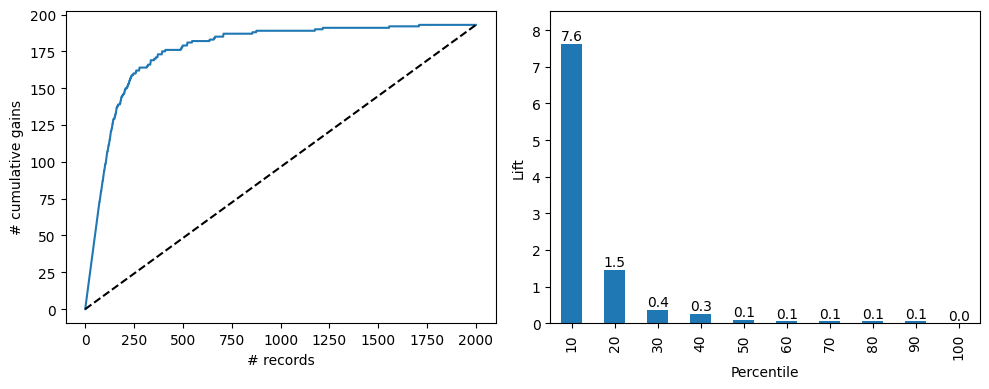

In [6]:
df = logit_result.sort_values(by=['p(1)'], ascending=False)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

gainsChart(df.actual, ax=axes[0])
liftChart(df.actual, title=False, ax=axes[1])

plt.tight_layout()
plt.show()

### 10.5 Logistic Regression for Multi-class Classification

**Ordinal and nominal (multi-class) regression in Python**

In [7]:
data = pd.read_csv(os.path.join('data', 'accidentsFull.csv'))
outcome = 'MAX_SEV_IR'
predictors = ['ALCHL_I', 'WEATHER_R']

y = data[outcome]
X = data[predictors]
train_X, train_y = X, y

print('Nominal logistic regression')
logit = LogisticRegression(penalty="l2", solver='lbfgs', C=1e24)
logit.fit(X, y)
print('  intercept', logit.intercept_)
print('  coefficients', logit.coef_)
print()
probs = logit.predict_proba(X)
results = pd.DataFrame({
    'actual': y, 'predicted': logit.predict(X),
    'P(0)': [p[0] for p in probs],
    'P(1)': [p[1] for p in probs],
    'P(2)': [p[2] for p in probs],
})
print(results.head())
print()

print('Ordinal logistic regression')
logit = LogisticIT(alpha=0)
logit.fit(X, y)
print('  theta', logit.theta_)
print('  coefficients', logit.coef_)
print()
probs = logit.predict_proba(X)
results = pd.DataFrame({
    'actual': y, 'predicted': logit.predict(X),
    'P(0)': [p[0] for p in probs],
    'P(1)': [p[1] for p in probs],
    'P(2)': [p[2] for p in probs],
})
results.head()

Nominal logistic regression
  intercept [-0.17870851  0.81673248 -0.63802397]
  coefficients [[ 0.52491466  0.40469045]
 [ 0.15763357  0.16071816]
 [-0.68254823 -0.56540861]]

   actual  predicted      P(0)      P(1)      P(2)
0       1          1  0.490569  0.498933  0.010498
1       0          0  0.554023  0.441483  0.004494
2       0          0  0.554023  0.441483  0.004494
3       0          1  0.490569  0.498933  0.010498
4       0          1  0.393700  0.578117  0.028183

Ordinal logistic regression
  theta [-1.06916285  2.77444326]
  coefficients [-0.40112008 -0.25174207]



,actual,predicted,P(0),P(1),P(2)
0,1,1,0.496205,0.482514,0.021281
1,0,0,0.558866,0.424510,0.016624
2,0,0,0.558866,0.424510,0.016624
3,0,1,0.496205,0.482514,0.021281
4,0,1,0.397402,0.571145,0.031453


### 10.6 Example of Complete Analysis: Predicting Delayed Flights

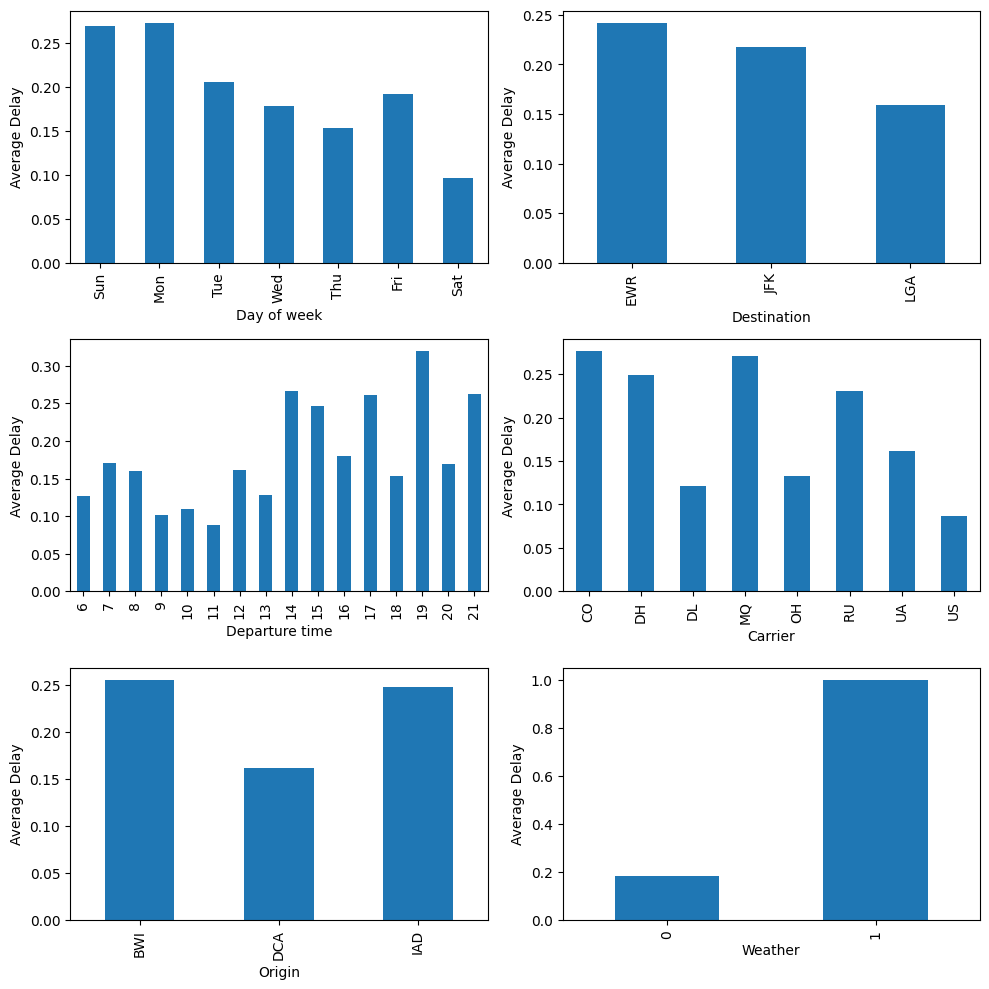

In [8]:
delays_df = pd.read_csv(os.path.join('data', 'FlightDelays.csv'))
# Create an indicator variable
delays_df['isDelayed'] = [1 if status == 'delayed' else 0 
                          for status in delays_df['Flight Status']]
           
def createGraph(group, xlabel, axis):
    groupAverage = delays_df.groupby([group])['isDelayed'].mean()
    if group == 'DAY_WEEK': # rotate so that display starts on Sunday
        groupAverage = groupAverage.reindex(index=np.roll(groupAverage.index,1))
        groupAverage.index = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
    ax = groupAverage.plot.bar(color='C0', ax=axis)
    ax.set_ylabel('Average Delay')
    ax.set_xlabel(xlabel)
    return ax
    
def graphDepartureTime(xlabel, axis):
    temp_df = pd.DataFrame({'CRS_DEP_TIME': delays_df['CRS_DEP_TIME'] // 100, 
                            'isDelayed': delays_df['isDelayed']})
    groupAverage = temp_df.groupby(['CRS_DEP_TIME'])['isDelayed'].mean()
    ax = groupAverage.plot.bar(color='C0', ax=axis)
    ax.set_xlabel(xlabel); ax.set_ylabel('Average Delay')
    
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))

createGraph('DAY_WEEK', 'Day of week', axis=axes[0][0])
createGraph('DEST', 'Destination', axis=axes[0][1])
graphDepartureTime('Departure time', axis=axes[1][0])
createGraph('CARRIER', 'Carrier', axis=axes[1][1])
createGraph('ORIGIN', 'Origin', axis=axes[2][0])
createGraph('Weather', 'Weather', axis=axes[2][1])
plt.tight_layout()

**Proportion of delayed flights by each of the six predictors. Time of day is divided into hourly bins**

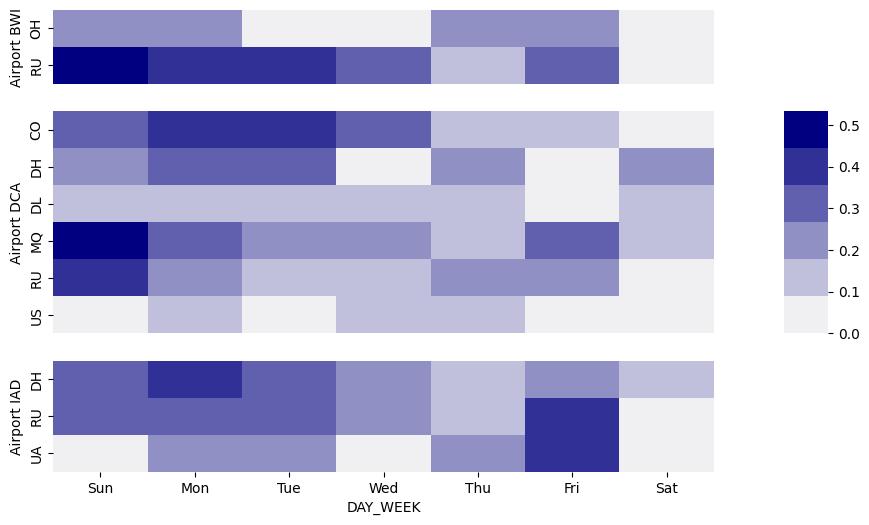

In [9]:
agg = delays_df.groupby(['ORIGIN', 'DAY_WEEK', 'CARRIER']).isDelayed.mean()
agg = agg.reset_index()

# Define the layout of the graph
height_ratios = []
for i, origin in enumerate(sorted(delays_df.ORIGIN.unique())):
    height_ratios.append(len(agg[agg.ORIGIN == origin].CARRIER.unique()))
gridspec_kw = {'height_ratios': height_ratios, 'width_ratios': [15, 1]}
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 6), 
                         gridspec_kw = gridspec_kw)
axes[0, 1].axis('off')
axes[2, 1].axis('off')

maxIsDelay = agg.isDelayed.max()
for i, origin in enumerate(sorted(delays_df.ORIGIN.unique())):
    data = pd.pivot_table(agg[agg.ORIGIN == origin], values='isDelayed', aggfunc='sum', 
                          index=['CARRIER'], columns=['DAY_WEEK'])
    data = data[[7, 1, 2, 3, 4, 5, 6]]  # Shift last columns to first
    ax = sns.heatmap(data, ax=axes[i][0], vmin=0, vmax=maxIsDelay, 
                     cbar_ax=axes[1][1], cmap=sns.light_palette("navy"))
    ax.set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'])
    if i != 2: 
        ax.get_xaxis().set_visible(False)
    ax.set_ylabel('Airport ' + origin)
plt.show()

**Estimated Logistic regression model for delayed flights (based on the training set)**

In [10]:
# convert to categorical
delays_df.DAY_WEEK = delays_df.DAY_WEEK.astype('category')

# create hourly bins departure time 
delays_df.CRS_DEP_TIME = [round(t / 100) for t in delays_df.CRS_DEP_TIME]
delays_df.CRS_DEP_TIME = delays_df.CRS_DEP_TIME.astype('category')

predictors = ['DAY_WEEK', 'CRS_DEP_TIME', 'ORIGIN', 'DEST', 'CARRIER', 'Weather']
outcome = 'isDelayed'

X = pd.get_dummies(delays_df[predictors], drop_first=True)
y = delays_df[outcome]
classes = ['ontime', 'delayed']

# split into training and validation
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=SEED)

logit_full = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_full.fit(train_X, train_y)

print('intercept ', logit_full.intercept_[0])
pd.DataFrame({'coeff': logit_full.coef_[0]}, index=X.columns).transpose()

intercept  -1.2191068769073172


,Weather,DAY_WEEK_2,DAY_WEEK_3,DAY_WEEK_4,DAY_WEEK_5,DAY_WEEK_6,DAY_WEEK_7,CRS_DEP_TIME_7,CRS_DEP_TIME_8,CRS_DEP_TIME_9,...,ORIGIN_IAD,DEST_JFK,DEST_LGA,CARRIER_DH,CARRIER_DL,CARRIER_MQ,CARRIER_OH,CARRIER_RU,CARRIER_UA,CARRIER_US
coeff,9.325014,-0.597928,-0.704795,-0.798678,-0.295774,-1.129236,-0.135377,0.631496,0.382262,-0.365022,...,-0.134055,-0.523642,-0.545662,0.352302,-0.684517,0.743163,-0.710518,-0.194203,0.315418,-0.97143


In [11]:
print('AIC', AIC_score(valid_y, logit_full.predict(valid_X), df = len(train_X.columns) + 1))

AIC 1004.5346225948085


**Evaluating performance of all-predictor model on validation**

Confusion Matrix (Accuracy 0.8309)

        Prediction
 Actual  ontime delayed
 ontime     705       9
delayed     140      27


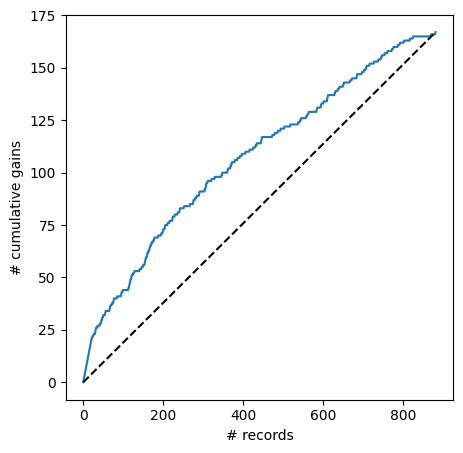

In [12]:
logit_reg_pred = logit_full.predict_proba(valid_X)
full_result = pd.DataFrame({'actual': valid_y, 
                            'p(0)': [p[0] for p in logit_reg_pred],
                            'p(1)': [p[1] for p in logit_reg_pred],
                            'predicted': logit_full.predict(valid_X)})
full_result = full_result.sort_values(by=['p(1)'], ascending=False)

# confusion matrix
classificationSummary(full_result.actual, full_result.predicted, class_names=classes)

gainsChart(full_result.actual, figsize=[5, 5])
plt.show()

**Logistic regression model with fewer predictors**

In [13]:
delays_df['CRS_DEP_TIME'] = [round(t / 100) for t in delays_df['CRS_DEP_TIME']]
delays_red_df = pd.DataFrame({
    'Sun_Mon' : [1 if d in (1, 7) else 0 for d in delays_df.DAY_WEEK],
    'Weather' : delays_df.Weather,
    'CARRIER_CO_MQ_DH_RU' : [1 if d in ("CO", "MQ", "DH", "RU") else 0 
                             for d in delays_df.CARRIER],
    'MORNING' : [1 if d in (6, 7, 8, 9) else 0 for d in delays_df.CRS_DEP_TIME],
    'NOON' : [1 if d in (10, 11, 12, 13) else 0 for d in delays_df.CRS_DEP_TIME],
    'AFTER2P' : [1 if d in (14, 15, 16, 17, 18) else 0 for d in delays_df.CRS_DEP_TIME],
    'EVENING' : [1 if d in (19, 20) else 0 for d in delays_df.CRS_DEP_TIME],
    'isDelayed' : [1 if status == 'delayed' else 0 for status in delays_df['Flight Status']],
})

X = delays_red_df.drop(columns=['isDelayed'])
y = delays_red_df['isDelayed']
classes = ['ontime', 'delayed']

# split into training and validation
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, 
                                                      random_state=SEED)
                        
logit_red = LogisticRegressionCV(penalty="l1", solver='liblinear', cv=5)
logit_red.fit(train_X, train_y)

print('intercept ', logit_red.intercept_[0])
pd.DataFrame({'coeff': logit_red.coef_[0]}, index=X.columns).transpose()


intercept  -2.509726593729543


,Sun_Mon,Weather,CARRIER_CO_MQ_DH_RU,MORNING,NOON,AFTER2P,EVENING
coeff,0.625337,4.920328,1.281507,0.0,0.0,0.0,0.0


In [14]:
print('AIC', AIC_score(valid_y, logit_red.predict(valid_X), df=len(train_X.columns) + 1))

# confusion matrix
classificationSummary(valid_y, logit_red.predict(valid_X), class_names=classes)

AIC 940.6290360089256
Confusion Matrix (Accuracy 0.8331)

        Prediction
 Actual  ontime delayed
 ontime     714       0
delayed     147      20


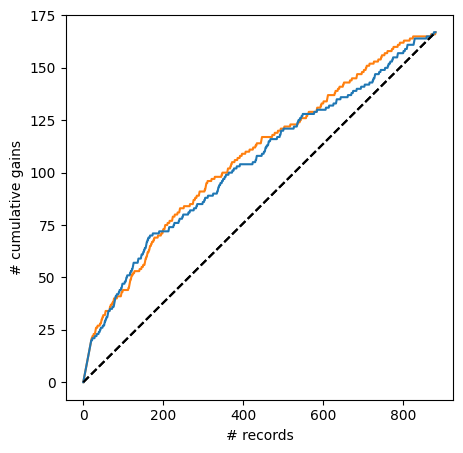

In [15]:
logit_reg_proba = logit_red.predict_proba(valid_X)
red_result = pd.DataFrame({'actual': valid_y, 
                            'p(0)': [p[0] for p in logit_reg_proba],
                            'p(1)': [p[1] for p in logit_reg_proba],
                            'predicted': logit_red.predict(valid_X),
                          })
red_result = red_result.sort_values(by=['p(1)'], ascending=False)

ax = gainsChart(full_result.actual, color='C1', figsize=[5, 5])
gainsChart(red_result.actual, color='C0', ax=ax)
plt.show()

**Logistic regression model for loan acceptance using Statmodels**

In [16]:
# add constant column
y = bank_df2['Personal_Loan']
X = bank_df2.drop(columns=['Personal_Loan'])
X = sm.add_constant(X, prepend=True)

# partition data
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=SEED)

# use GLM (general linear model) with the binomial family to fit a logistic regression
logit_reg = sm.GLM(train_y, train_X, family=sm.families.Binomial())
logit_result = logit_reg.fit()
logit_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:          Personal_Loan   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2987
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -340.15
Date:                Mon, 07 Apr 2025   Deviance:                       680.30
Time:                        07:32:46   Pearson chi2:                 8.10e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3325
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                             -12.5634      2.336     -5.377      0.000     -17.143      -7.984
Age                                -0.0354      0.086     -0.412      0.680      -0.204       0.133
Experience                          0.0369      0.086      0.431      0.666      -0.131       0.205
Income                              0.0589      0.004     15.044      0.000       0.051       0.067
Family                              0.6128      0.103      5.931      0.000       0.410       0.815
CCAvg                               0.2408      0.060      4.032      0.000       0.124       0.358
Mortgage                            0.0010      0.001      1.301      0.193      -0.001       0.003
Securities_Account                 -1.0305      0.422     -2.443      0.015      -1.857      -0.204
CD_Account                          3.6628      0.460      7.961      0.000       2.761       4.565
Online                             -0.6794      0.216     -3.140      0.002      -1.103      -0.255
CreditCard                         -0.9609      0.274     -3.507      0.000      -1.498      -0.424
Education_Graduate                  4.2075      0.364     11.573      0.000       3.495       4.920
Education_Advanced/Professional     4.3580      0.365     11.937      0.000       3.642       5.074
===================================================================================================
"""